In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [27]:
df = pd.read_csv('/content/Corporate_Financial_Risk_Assessment_Data.csv')

print("Gaps found per column:")
print(df.isnull().sum())

df = df.fillna(df.median(numeric_only=True))

print("\n--- Scrub Complete ---")
print("Your data is clean and ready for modeling.")

Gaps found per column:
Company_ID               0
Date                     0
Industry_Sector          0
Total_Assets             0
Total_Liabilities        0
Current_Assets           0
Current_Liabilities      0
Net_Income               0
Revenue                  0
Operating_Income         0
Cash_Flow                0
Debt_Equity_Ratio        0
Return_on_Assets         0
Working_Capital_Ratio    0
Stock_Price_Close        0
Volatility_Index         0
GDP_Growth_Rate          0
Interest_Rate            0
Inflation_Rate           0
Financial_Risk_Label     0
dtype: int64

--- Scrub Complete ---
Your data is clean and ready for modeling.


In [28]:
X = df.drop(columns=['Financial_Risk_Label', 'Company_ID', 'Date', 'Industry_Sector'])

y = df['Financial_Risk_Label']

print(f"Features (X) shape: {X.shape} (Rows, Columns)")
print(f"Target (y) shape: {y.shape} (Rows)")

print("\nFinal Modeling Features:")
print(X.columns.tolist())

Features (X) shape: (5000, 16) (Rows, Columns)
Target (y) shape: (5000,) (Rows)

Final Modeling Features:
['Total_Assets', 'Total_Liabilities', 'Current_Assets', 'Current_Liabilities', 'Net_Income', 'Revenue', 'Operating_Income', 'Cash_Flow', 'Debt_Equity_Ratio', 'Return_on_Assets', 'Working_Capital_Ratio', 'Stock_Price_Close', 'Volatility_Index', 'GDP_Growth_Rate', 'Interest_Rate', 'Inflation_Rate']


In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Shuffle & Split Complete ---")
print(f"Training Pile: {X_train.shape[0]} companies (The Textbook)")
print(f"Testing Pile:  {X_test.shape[0]} companies (The Final Exam)")

--- Shuffle & Split Complete ---
Training Pile: 4000 companies (The Textbook)
Testing Pile:  1000 companies (The Final Exam)


In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("--- Model Training Complete ---")
print("The model has calculated the risk weights for your 16 features.")

--- Model Training Complete ---
The model has calculated the risk weights for your 16 features.


In [32]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("--- Final Exam Results ---")
print(f"Model Accuracy: {accuracy * 100:.2f}%")

--- Final Exam Results ---
Model Accuracy: 89.40%


In [33]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Weight': model.coef_[0]
}).sort_values(by='Weight', ascending=False)

print("--- The Final Risk Scorecard ---")
print(importance)

--- The Final Risk Scorecard ---
                  Feature        Weight
11      Stock_Price_Close  5.904964e-04
10  Working_Capital_Ratio  4.965059e-05
12       Volatility_Index  4.208734e-05
8       Debt_Equity_Ratio  5.544216e-06
14          Interest_Rate  5.543481e-06
15         Inflation_Rate  4.404078e-06
7               Cash_Flow  8.024224e-07
13        GDP_Growth_Rate  3.903658e-07
1       Total_Liabilities  3.114560e-08
6        Operating_Income  7.944253e-09
2          Current_Assets  9.282358e-11
5                 Revenue -9.635259e-10
3     Current_Liabilities -1.080335e-09
0            Total_Assets -1.932674e-08
9        Return_on_Assets -1.207018e-07
4              Net_Income -8.182247e-07


In [34]:
new_company = [[
    1000000,  # Total_Assets
    400000,   # Total_Liabilities
    300000,   # Current_Assets
    200000,   # Current_Liabilities
    150000,   # Net_Income
    2000000,  # Revenue
    400000,   # Operating_Income
    100000,   # Cash_Flow
    1.3,      # Debt_Equity_Ratio
    0.15,     # Return_on_Assets
    1.5,      # Working_Capital_Ratio
    250.00,   # Stock_Price_Close
    18.5,     # Volatility_Index
    0.03,     # GDP_Growth_Rate
    0.05,     # Interest_Rate
    0.02      # Inflation_Rate
]]

verdict = model.predict(new_company)
confidence = model.predict_proba(new_company)

print("--- Professional Underwriting Verdict ---")
if verdict[0] == 1:
    print("STATUS: REJECTED - High Default Risk")
else:
    print("STATUS: APPROVED - Low Default Risk")

print(f"Confidence Level: {confidence.max() * 100:.2f}%")

--- Professional Underwriting Verdict ---
STATUS: REJECTED - High Default Risk
Confidence Level: 52.50%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


/tmp/ipykernel_431/3076975802.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(


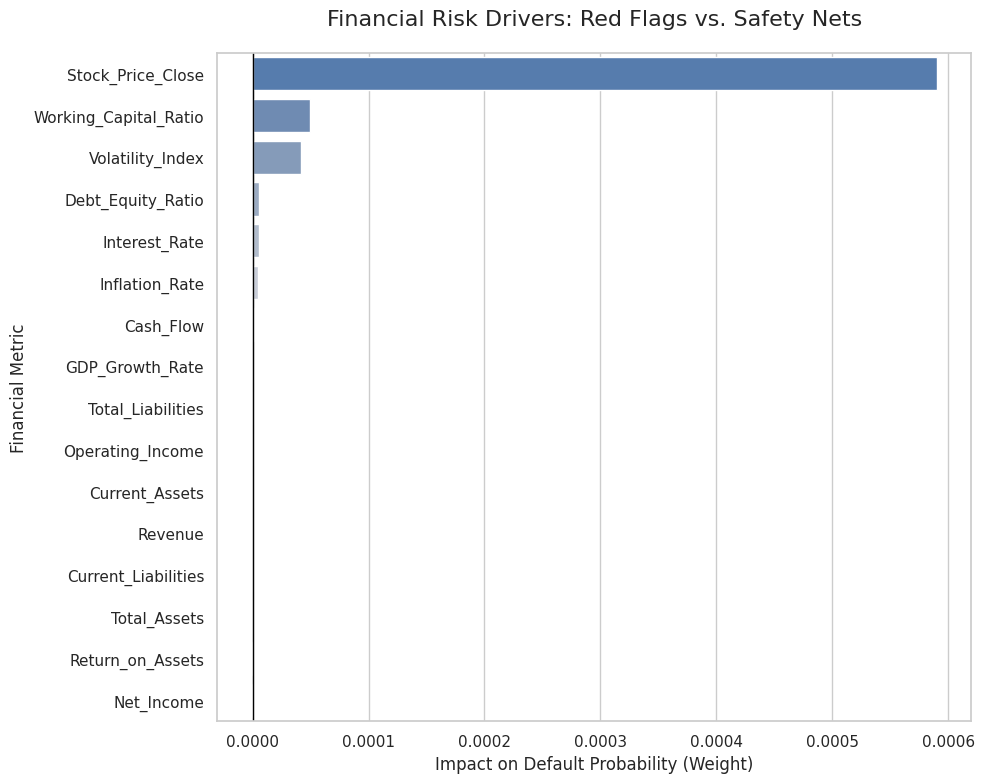

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

plot = sns.barplot(
    x='Weight',
    y='Feature',
    data=importance,
    palette='vlag'
)

plt.axvline(x=0, color='black', linestyle='-', linewidth=1)

plt.title('Financial Risk Drivers: Red Flags vs. Safety Nets', fontsize=16, pad=20)
plt.xlabel('Impact on Default Probability (Weight)', fontsize=12)
plt.ylabel('Financial Metric', fontsize=12)

plt.tight_layout()
plt.show()